# ML algoritmų ir skirtingu možymių sudarymo metodų taikymas klasifiekuojant į emocines klases #

In [4]:
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
import xgboost as XGB
from docx import Document
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

## DUOMENŲ NUSKAITYMAS ##

In [5]:
def read_text(path):
    doc = Document(path)
    return "\n".join(p.text.strip() for p in doc.paragraphs if p.text.strip())

def build_df(paths, label):
    texts = []
    
    for path in paths:
        full_text = read_text(path)
        sentences = [s.strip() for s in full_text.split("\n") if s.strip()]
        
        for s in sentences:
            texts.append({
                "sentence": s,
                "label": label
            })
    
    return pd.DataFrame(texts)

In [6]:
D_paths = [
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\DŽIAUGSMAS_1.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\DŽIAUGSMAS_2.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\DŽIAUGSMAS_3_4_2026.docx",
]

L_paths = [
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\LIŪDESYS_1.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\LIŪDESYS_2.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\LIŪDESYS_3_4_2026.docx",
]

N_paths = [
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NUOSTABA_1.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NUOSTABA_2.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NUOSTABA_3_4_2026.docx",
]

P_paths = [
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\PYKTIS_1.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\PYKTIS_2.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\PYKTIS_3_4_2026.docx",
]

Z_paths = [
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NEUTRALUS_1.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NEUTRALUS_2.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NEUTRALUS_3.docx",
    r"C:\Users\ignas\Desktop\NLP_BAK\Duomenys_2\NEUTRALUS_2026_1.docx",
]

In [7]:
df = pd.concat([
    build_df(D_paths, "džiaugsmas"),
    build_df(L_paths, "liūdesys"),
    build_df(N_paths, "nuostaba"),
    build_df(P_paths, "pyktis"),
    build_df(Z_paths, "neutralus"),
], ignore_index=True)

In [8]:
print(df)


                                               sentence       label
0                        – Matai, kiek žibuoklių radau!  džiaugsmas
1                     Puikus buvo tada metas, vyručiai!  džiaugsmas
2              O dabar metas į puotą, kuri mūsų laukia!  džiaugsmas
3                          Linksminkitės, mano draugai!  džiaugsmas
4                                         – Kaip gražu!  džiaugsmas
...                                                 ...         ...
6936  Visgi, tėveliai dažniausiai išreiškia didelį d...   neutralus
6937  – Kaip vertinate bendrą etninės kultūros ugdym...   neutralus
6938  – Šia linkme nesu atlikusi specialių tyrimų, t...   neutralus
6939  Juk be mokyklos, be ugdymo įstaigų, visko prad...   neutralus
6940  Netgi, jei mokykloje ir nėra etninės kultūros ...   neutralus

[6941 rows x 2 columns]


### PATIKRINIMAS DĖK DUBLIKATŲ ###

In [9]:
print('Viso eilučių skaičius:', len(df))

print('Dublikatų skaičius:',
      df.duplicated(subset=["sentence"]).sum())

print('Unikalių eilučių skaičius:',
      df["sentence"].nunique())

print('Dublikatai pagal kiekvieną emocija:',
      df.groupby("label")["sentence"]
        .apply(lambda x: x.duplicated().sum()))


Viso eilučių skaičius: 6941
Dublikatų skaičius: 0
Unikalių eilučių skaičius: 6941
Dublikatai pagal kiekvieną emocija: label
džiaugsmas    0
liūdesys      0
neutralus     0
nuostaba      0
pyktis        0
Name: sentence, dtype: int64


## STEBĖJIMŲ SKAIČIUS ##

label
džiaugsmas    1628
pyktis        1544
nuostaba      1522
neutralus     1172
liūdesys      1075
Name: count, dtype: int64
label
džiaugsmas    0.234548
pyktis        0.222446
nuostaba      0.219277
neutralus     0.168852
liūdesys      0.154877
Name: proportion, dtype: float64


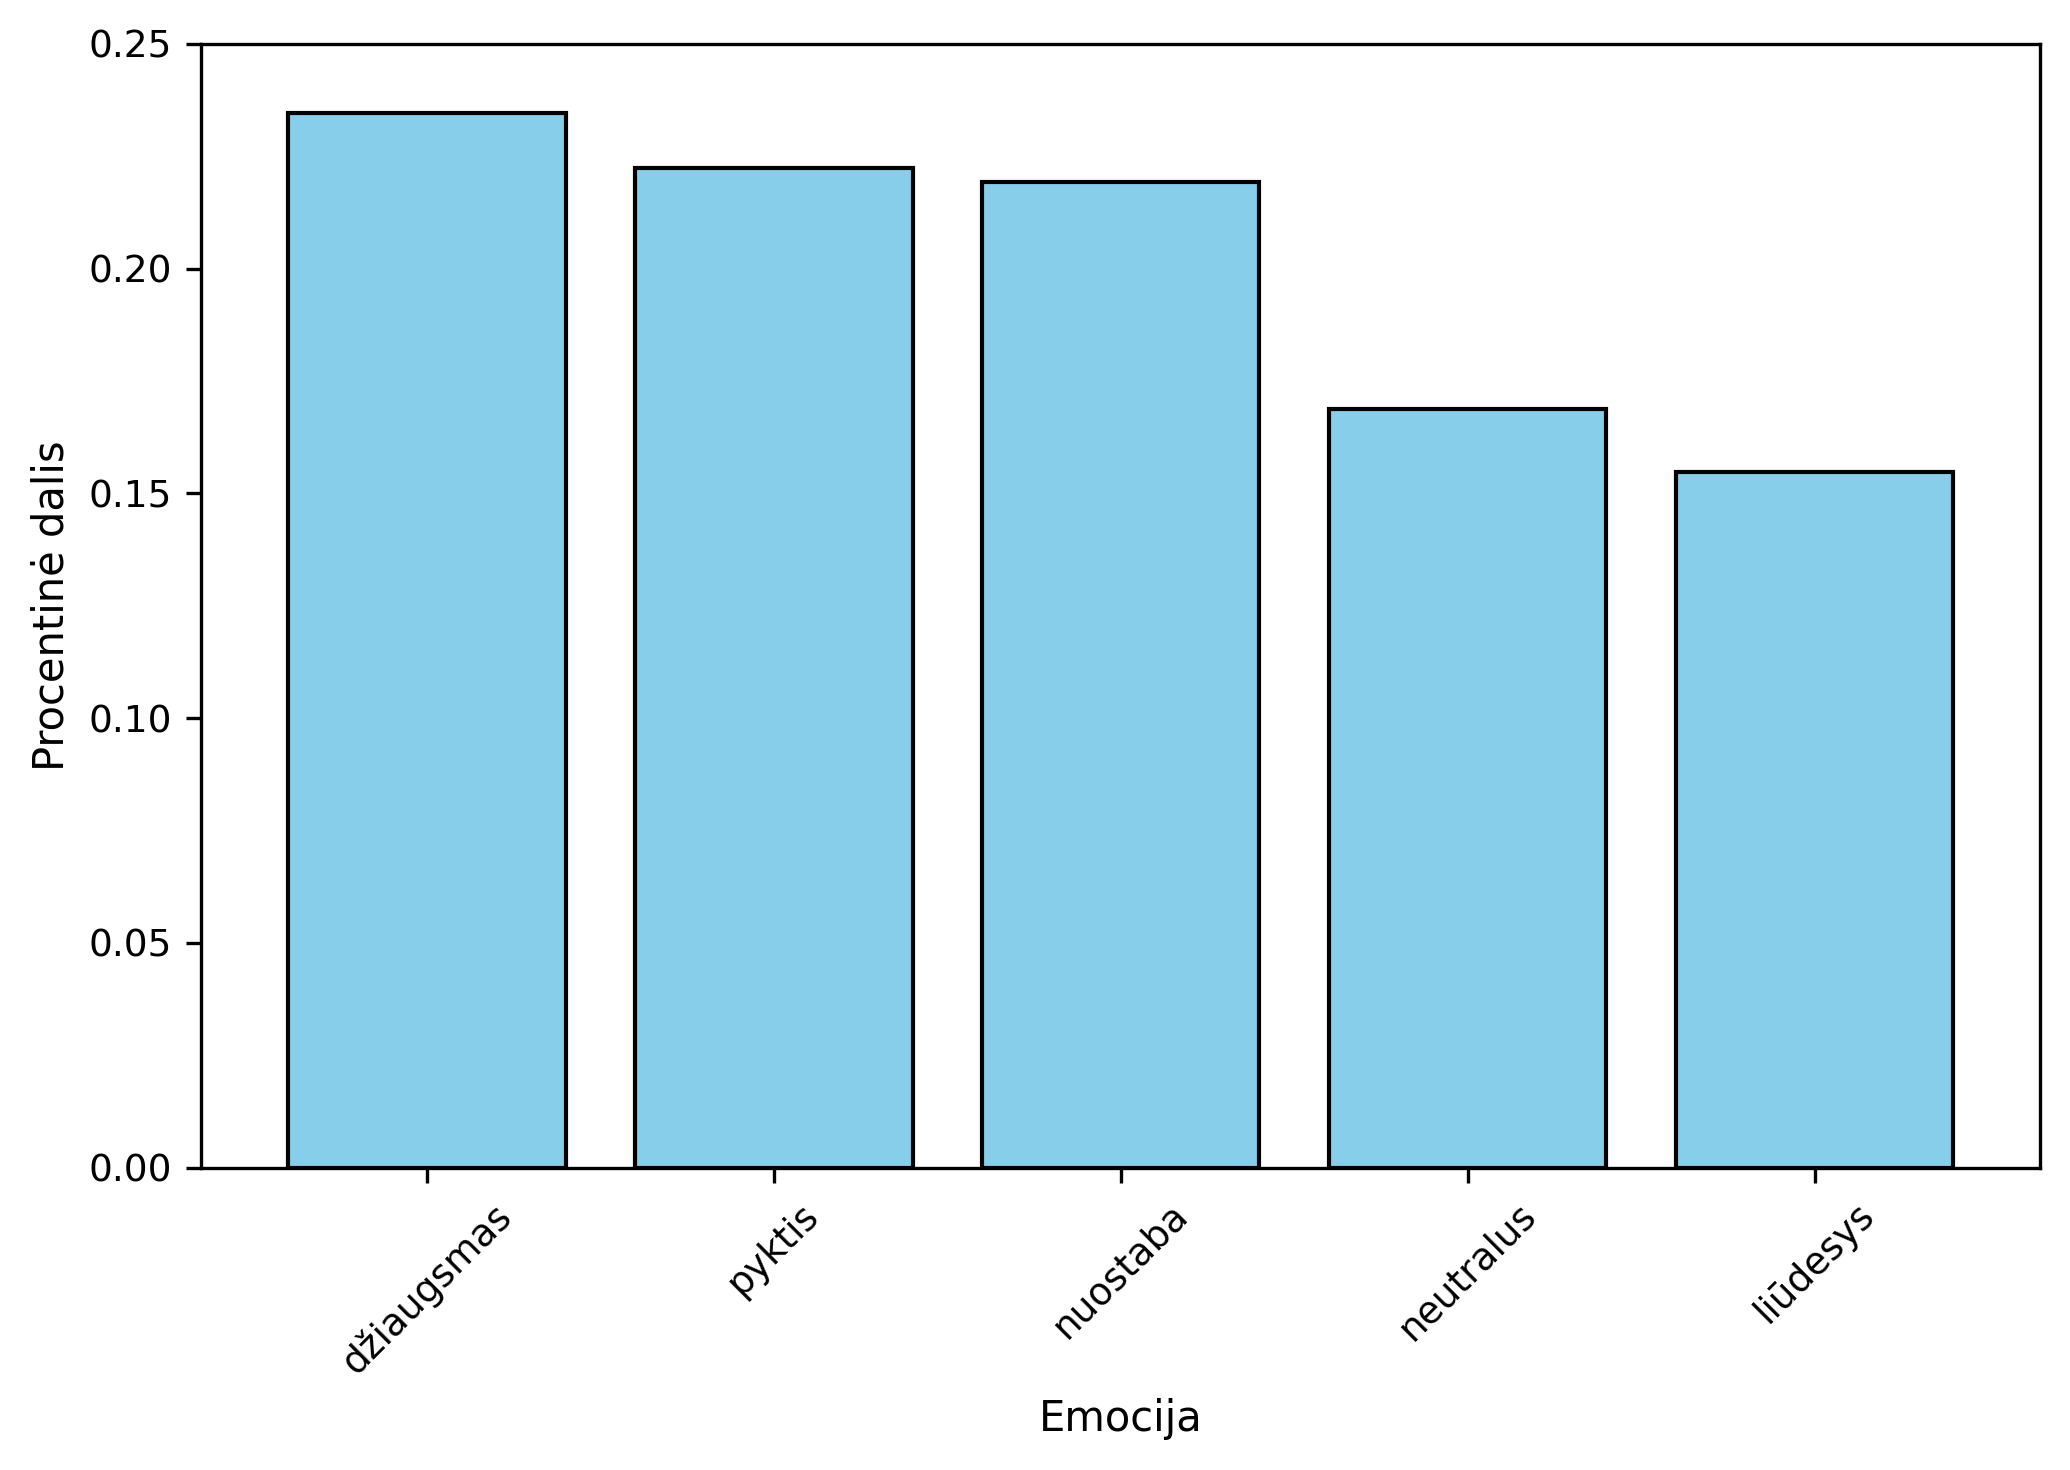

In [10]:
label_counts = df['label'].value_counts().sort_values(ascending=False)
label_count_normalized = df['label'].value_counts(normalize=True).sort_values(ascending=False)
print(label_counts)
print(label_count_normalized)

plt.figure(figsize=(7, 5), dpi=300)

label_count_normalized.plot(
    kind="bar",
    color="skyblue",         
    edgecolor="black",
    width=0.8
)
plt.xlabel("Emocija", fontsize=10)
plt.ylabel("Procentinė dalis", fontsize=10)
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)
plt.ylim(0, 0.25)
#plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("emociju_skaičius.png", bbox_inches="tight", dpi=300)
plt.show()


## LINGVIT. IR MORFOLOG. POŽYMIŲ SUDARYMAS ##

In [11]:
import spacy
nlp = spacy.load("lt_core_news_sm")

def preprocess_text(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    return " ".join(tokens)

df['processed_sentence'] = df['sentence'].apply(preprocess_text)

In [12]:
from collections import Counter

def text_features(text: str) -> dict:
    if text is None:
        text = ""
    doc = nlp(text)

    tokens = [t for t in doc if not t.is_space]
    words = [t for t in tokens if t.is_alpha]
    n_tokens = len(tokens)
    n_words = len(words)
    n_chars = len(text)

    n_stop = sum(1 for t in words if t.is_stop)
    n_punct = sum(1 for t in tokens if t.is_punct)
    n_digits = sum(1 for t in tokens if t.like_num or t.is_digit)
    n_upper = sum(1 for t in tokens if t.text.isupper() and t.is_alpha)
    n_title = sum(1 for t in tokens if t.text.istitle())

    punct_counts = Counter(t.text for t in tokens if t.is_punct)
    n_excl = punct_counts.get("!", 0)
    n_q = punct_counts.get("?", 0)
    n_period = punct_counts.get(".", 0)
    n_comma = punct_counts.get(",", 0)
    n_colon = punct_counts.get(":", 0)
    n_semi = punct_counts.get(";", 0)

    pos_counts = Counter(t.pos_ for t in tokens)
    pos_feats = {
        "pos_NOUN": pos_counts.get("NOUN", 0),
        "pos_VERB": pos_counts.get("VERB", 0),
        "pos_ADJ": pos_counts.get("ADJ", 0),
        "pos_ADV": pos_counts.get("ADV", 0),
        "pos_PRON": pos_counts.get("PRON", 0),
        "pos_PROPN": pos_counts.get("PROPN", 0),
        "pos_ADP": pos_counts.get("ADP", 0),
        "pos_DET": pos_counts.get("DET", 0),
        "pos_CCONJ": pos_counts.get("CCONJ", 0),
        "pos_SCONJ": pos_counts.get("SCONJ", 0),
        "pos_PART": pos_counts.get("PART", 0),
        "pos_INTJ": pos_counts.get("INTJ", 0),
        "pos_SYM": pos_counts.get("SYM", 0),
        "pos_X": pos_counts.get("X", 0),
    }

    avg_word_len = (sum(len(t.text) for t in words) / n_words) if n_words else 0.0

    feats = {
        "n_chars": n_chars,
        "n_tokens": n_tokens,
        "n_words": n_words,
        "n_stopwords": n_stop,
        "n_punct": n_punct,
        "n_digits": n_digits,
        "n_upper_words": n_upper,
        "n_title_words": n_title,
        "avg_word_len": avg_word_len,

        "n_exclamation": n_excl,
        "n_question": n_q,
        "n_period": n_period,
        "n_comma": n_comma,
        "n_colon": n_colon,
        "n_semicolon": n_semi,

    }

    feats.update(pos_feats)
    return feats


feat_df = df["sentence"].fillna("").apply(text_features).apply(pd.Series)

df_bendras = pd.concat([df, feat_df], axis=1)


In [13]:
print(df_bendras)

                                               sentence       label  \
0                        – Matai, kiek žibuoklių radau!  džiaugsmas   
1                     Puikus buvo tada metas, vyručiai!  džiaugsmas   
2              O dabar metas į puotą, kuri mūsų laukia!  džiaugsmas   
3                          Linksminkitės, mano draugai!  džiaugsmas   
4                                         – Kaip gražu!  džiaugsmas   
...                                                 ...         ...   
6936  Visgi, tėveliai dažniausiai išreiškia didelį d...   neutralus   
6937  – Kaip vertinate bendrą etninės kultūros ugdym...   neutralus   
6938  – Šia linkme nesu atlikusi specialių tyrimų, t...   neutralus   
6939  Juk be mokyklos, be ugdymo įstaigų, visko prad...   neutralus   
6940  Netgi, jei mokykloje ir nėra etninės kultūros ...   neutralus   

                                     processed_sentence  n_chars  n_tokens  \
0                                Matai žibuoklius radau     30.0     

## DUOMENŲ SKAIDYMAS ##

In [14]:
df_train, df_test = train_test_split(df_bendras, test_size=0.2, random_state=0, stratify=df_bendras["label"])

y_train = df_train["label"]
y_test = df_test["label"]

y_train_enc = y_train.astype("category").cat.codes
y_test_enc = y_test.astype("category").cat.codes

X_train_text = df_train["processed_sentence"]
X_test_text = df_test["processed_sentence"]

X_train_feats = df_train.drop(columns=["sentence", "processed_sentence", "label"])
X_test_feats = df_test.drop(columns=["sentence", "processed_sentence", "label"])

X_train_combined = pd.concat([X_train_text, X_train_feats], axis=1)
X_test_combined = pd.concat([X_test_text, X_test_feats], axis=1)

text_stulp = "processed_sentence"
skait_stulp = X_train_feats.columns.tolist()

X_text = df_bendras["processed_sentence"]
X_feats = df_bendras[skait_stulp]
X_bendras = pd.concat([X_text, X_feats], axis=1)
y = df_bendras["label"]
y_enc = y.astype("category").cat.codes

In [15]:
df_bendras

,sentence,label,processed_sentence,n_chars,n_tokens,n_words,n_stopwords,n_punct,n_digits,n_upper_words,...,pos_PRON,pos_PROPN,pos_ADP,pos_DET,pos_CCONJ,pos_SCONJ,pos_PART,pos_INTJ,pos_SYM,pos_X
0,"– Matai, kiek žibuoklių radau!",džiaugsmas,Matai žibuoklius radau,30.0,7.0,4.0,1.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"Puikus buvo tada metas, vyručiai!",džiaugsmas,Puikus būti tada meti vyručis,33.0,7.0,5.0,0.0,2.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"O dabar metas į puotą, kuri mūsų laukia!",džiaugsmas,dabar metas puota laukti,40.0,10.0,8.0,4.0,2.0,0.0,1.0,...,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,"Linksminkitės, mano draugai!",džiaugsmas,Linksminkitės draugas,28.0,5.0,3.0,1.0,2.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,– Kaip gražu!,džiaugsmas,gražu,13.0,4.0,2.0,1.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6936,"Visgi, tėveliai dažniausiai išreiškia didelį d...",neutralus,tėveliai dažnai išreiškti didelis džiuguo vaik...,601.0,101.0,80.0,27.0,21.0,0.0,0.0,...,6.0,1.0,3.0,6.0,5.0,1.0,2.0,0.0,0.0,1.0
6937,– Kaip vertinate bendrą etninės kultūros ugdym...,neutralus,vertinate bendras etninis kultūra ugdymas situ...,68.0,10.0,8.0,1.0,2.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6938,"– Šia linkme nesu atlikusi specialių tyrimų, t...",neutralus,linkme nesas atlikti specialis tyrimas dažnai ...,424.0,72.0,59.0,21.0,13.0,1.0,0.0,...,2.0,0.0,2.0,4.0,5.0,4.0,3.0,0.0,0.0,0.0
6939,"Juk be mokyklos, be ugdymo įstaigų, visko prad...",neutralus,mokykla ugdymas įstaiga viskas pradžių prasti ...,295.0,51.0,43.0,17.0,8.0,0.0,0.0,...,4.0,0.0,6.0,1.0,4.0,0.0,2.0,0.0,0.0,4.0


In [16]:
print(skait_stulp)

['n_chars', 'n_tokens', 'n_words', 'n_stopwords', 'n_punct', 'n_digits', 'n_upper_words', 'n_title_words', 'avg_word_len', 'n_exclamation', 'n_question', 'n_period', 'n_comma', 'n_colon', 'n_semicolon', 'pos_NOUN', 'pos_VERB', 'pos_ADJ', 'pos_ADV', 'pos_PRON', 'pos_PROPN', 'pos_ADP', 'pos_DET', 'pos_CCONJ', 'pos_SCONJ', 'pos_PART', 'pos_INTJ', 'pos_SYM', 'pos_X']


## Naudojant tik lingvist ir morfolog požymius ##

### Logistinė regresija (LR) ###

In [17]:
pipe_lg_feat = Pipeline([
    ("clf", LogisticRegression(max_iter=3000))
])

param_grid_lg = {
    "clf__C": [0.1, 1, 5, 10],
    "clf__penalty": ['l2', 'l1'],
    "clf__solver": ['liblinear']
}

gs_lg_feat = GridSearchCV(
    pipe_lg_feat, param_grid_lg,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_lg_feat.fit(X_train_feats, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__penalty': ['l2', 'l1'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [18]:
print("Optimalus parametrai:", gs_lg_feat.best_params_)
print("Geriausia f1_macro reikšmė:", gs_lg_feat.best_score_)

cv_scores_lg_feat = cross_val_score(
    gs_lg_feat.best_estimator_,
    X_feats,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_lg_feat = gs_lg_feat.predict(X_test_feats)
print(classification_report(y_test, y_pred_lg_feat, digits=4))

Optimalus parametrai: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Geriausia f1_macro reikšmė: 0.6123953537757088


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation

              precision    recall  f1-score   support

  džiaugsmas     0.6135    0.8374    0.7082       326
    liūdesys     0.5708    0.6186    0.5938       215
   neutralus     0.6983    0.7222    0.7101       234
    nuostaba     0.5815    0.3508    0.4376       305
      pyktis     0.5754    0.5307    0.5522       309

    accuracy                         0.6091      1389
   macro avg     0.6079    0.6120    0.6004      1389
weighted avg     0.6057    0.6091    0.5967      1389



### Atraminių vektorių (SVM) ###

In [19]:
pipe_svm_feat = Pipeline([
    ("clf", LinearSVC(max_iter=3000))
])

param_grid_svm = [
    {
        "clf__C": [0.1, 1, 5, 10],
        "clf__loss": ["hinge", "squared_hinge"],
        "clf__penalty": ["l2"],
    },
    {
        "clf__C": [0.1, 1, 5, 10],
        "clf__loss": ["squared_hinge"],
        "clf__penalty": ["l1"],
        "clf__dual": [False],       
}
]

gs_svm_feat = GridSearchCV(
    pipe_svm_feat, param_grid_svm,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_feat.fit(X_train_feats, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [20]:
print("Optimalus parametrai:", gs_svm_feat.best_params_)
print("Optimali f1_macro reikšmė:", gs_svm_feat.best_score_)

cv_scores_svm_feat = cross_val_score(
    gs_svm_feat.best_estimator_,
    X_feats,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_svm_feat = gs_svm_feat.predict(X_test_feats)
print(classification_report(y_test, y_pred_svm_feat, digits=4))

Optimalus parametrai: {'clf__C': 0.1, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l2'}
Optimali f1_macro reikšmė: 0.6021332509518558
              precision    recall  f1-score   support

  džiaugsmas     0.6043    0.8528    0.7074       326
    liūdesys     0.5597    0.6326    0.5939       215
   neutralus     0.6926    0.7222    0.7071       234
    nuostaba     0.6250    0.3115    0.4158       305
      pyktis     0.5621    0.5275    0.5442       309

    accuracy                         0.6055      1389
   macro avg     0.6087    0.6093    0.5937      1389
weighted avg     0.6074    0.6055    0.5894      1389



### Naivusis Bajesas (NB) ###

In [21]:
pipe_nb_feat = Pipeline([
    ("clf", MultinomialNB())
])

param_grid_nb = [
        {"clf__alpha": np.arange(0.1, 2.1, 0.1)}
]

gs_nb_feat = GridSearchCV(
    pipe_nb_feat, param_grid_nb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_nb_feat.fit(X_train_feats, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.2


In [22]:
print("Optimalus parametrai:", gs_nb_feat.best_params_)
print("Geriausia f1_macro reikšmė:", gs_nb_feat.best_score_)

cv_scores_nb_feat = cross_val_score(
    gs_nb_feat.best_estimator_,
    X_feats,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_nb_feat = gs_nb_feat.predict(X_test_feats)
print(classification_report(y_test, y_pred_nb_feat, digits=4))


Optimalus parametrai: {'clf__alpha': 0.2}
Geriausia f1_macro reikšmė: 0.5726779783784701
              precision    recall  f1-score   support

  džiaugsmas     0.6481    0.6779    0.6627       326
    liūdesys     0.4715    0.4233    0.4461       215
   neutralus     0.7087    0.6239    0.6636       234
    nuostaba     0.4116    0.3967    0.4040       305
      pyktis     0.5352    0.6149    0.5723       309

    accuracy                         0.5536      1389
   macro avg     0.5550    0.5473    0.5497      1389
weighted avg     0.5539    0.5536    0.5524      1389



### XGBoost (XGB) ###

In [23]:
pipe_xgb_feat = Pipeline([
    ("clf", XGB.XGBClassifier())
])

param_grid_xgb = {
    "clf__n_estimators": [100, 150, 200],
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.01, 0.1],  
    "clf__eval_metric": ["mlogloss", "logloss"]
}

gs_xgb_feat = GridSearchCV(
    pipe_xgb_feat, param_grid_xgb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)

gs_xgb_feat.fit(X_train_feats, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [24]:
print("Optimalus parametrai:", gs_xgb_feat.best_params_)
print("Geriausia f1_macro reikšmė:", gs_xgb_feat.best_score_)

cv_scores_xgb_feat = cross_val_score(
    gs_xgb_feat.best_estimator_,
    X_feats,
    y_enc,
    cv=5,
    scoring="f1_macro"
)

y_pred_xgb_feat = gs_xgb_feat.predict(X_test_feats)
print(classification_report(y_test_enc, y_pred_xgb_feat, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'mlogloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.6558193811633022
              precision    recall  f1-score   support

           0     0.6769    0.8098    0.7374       326
           1     0.6195    0.5907    0.6048       215
           2     0.7585    0.7650    0.7617       234
           3     0.6000    0.5410    0.5690       305
           4     0.6007    0.5502    0.5743       309

    accuracy                         0.6515      1389
   macro avg     0.6511    0.6513    0.6494      1389
weighted avg     0.6479    0.6515    0.6477      1389



### Atsitiktinių miškų (RF) ###

In [25]:
pipe_rf_feat = Pipeline([
    ("clf", RandomForestClassifier(random_state=0))
])

param_grid_rf = {
    "clf__n_estimators": [100, 150, 200],
    "clf__max_depth": [3, 5],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 2]
}

gs_rf_feat = GridSearchCV(
    pipe_rf_feat, param_grid_rf,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_feat.fit(X_train_feats, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [26]:
print("Optimalus parametrai:", gs_rf_feat.best_params_)
print("Geriausia f1_macro reikšmė:", gs_rf_feat.best_score_)

cv_scores_rf_feat = cross_val_score(
    gs_rf_feat.best_estimator_,
    X_feats,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_rf_feat = gs_rf_feat.predict(X_test_feats)
print(classification_report(y_test, y_pred_rf_feat, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.6079864701356922
              precision    recall  f1-score   support

  džiaugsmas     0.6057    0.8528    0.7083       326
    liūdesys     0.5964    0.4605    0.5197       215
   neutralus     0.7250    0.7436    0.7342       234
    nuostaba     0.5379    0.5115    0.5244       305
      pyktis     0.6325    0.4790    0.5451       309

    accuracy                         0.6156      1389
   macro avg     0.6195    0.6095    0.6063      1389
weighted avg     0.6154    0.6156    0.6068      1389



## NAUDOJANT TF-IDF IR BOW ##

### Logistinė regresija (LR) + TF-IDF ###

In [27]:
pipe_lg_tfidf_text = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=3000))
])

gs_lg_tfidf_text = GridSearchCV(
    pipe_lg_tfidf_text, param_grid_lg,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_lg_tfidf_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__penalty': ['l2', 'l1'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [28]:
print("Optimalus parametrai:", gs_lg_tfidf_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_lg_tfidf_text.best_score_)

cv_scores_lg_tfidf_text = cross_val_score(
    gs_lg_tfidf_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_lg_tfidf_text = gs_lg_tfidf_text.predict(X_test_text)
print(classification_report(y_test, y_pred_lg_tfidf_text, digits=4))

Optimalus parametrai: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Geriausia f1_macro reikšmė: 0.7355854564207982


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation

              precision    recall  f1-score   support

  džiaugsmas     0.8062    0.8037    0.8049       326
    liūdesys     0.6927    0.6186    0.6536       215
   neutralus     0.7710    0.8632    0.8145       234
    nuostaba     0.7579    0.7082    0.7322       305
      pyktis     0.6708    0.7055    0.6877       309

    accuracy                         0.7423      1389
   macro avg     0.7397    0.7398    0.7386      1389
weighted avg     0.7420    0.7423    0.7411      1389



### Logistinė regresija (LR) + BOW ###

In [29]:
pipe_lg_cv_text = Pipeline([
    ("cv", CountVectorizer()),
    ("clf", LogisticRegression(max_iter=3000))
])

gs_lg_cv_text = GridSearchCV(
    pipe_lg_cv_text, param_grid_lg,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_lg_cv_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__penalty': ['l2', 'l1'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [30]:
print("Optimalus parametrai:", gs_lg_cv_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_lg_cv_text.best_score_)

cv_scores_lg_cv_text = cross_val_score(
    gs_lg_cv_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_lg_cv_text = gs_lg_cv_text.predict(X_test_text)
print(classification_report(y_test, y_pred_lg_cv_text, digits=4))

Optimalus parametrai: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Geriausia f1_macro reikšmė: 0.7177100019071457


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation

              precision    recall  f1-score   support

  džiaugsmas     0.7672    0.7883    0.7776       326
    liūdesys     0.7500    0.5581    0.6400       215
   neutralus     0.8592    0.7821    0.8188       234
    nuostaba     0.7354    0.7016    0.7181       305
      pyktis     0.6077    0.7670    0.6781       309

    accuracy                         0.7279      1389
   macro avg     0.7439    0.7194    0.7265      1389
weighted avg     0.7376    0.7279    0.7280      1389



C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


### Atraminių vektorių (SVM) + TF-IDF ###

In [31]:
pipe_svm_tfidf_text = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC(max_iter=3000))
])

gs_svm_tfidf_text = GridSearchCV(
    pipe_svm_tfidf_text, param_grid_svm,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_tfidf_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [32]:
print("Optimalus parametrai:", gs_svm_tfidf_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_svm_tfidf_text.best_score_)

cv_scores_svm_tfidf_text = cross_val_score(
    gs_svm_tfidf_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)


y_pred_svm_tfidf_text = gs_svm_tfidf_text.predict(X_test_text)
print(classification_report(y_test, y_pred_svm_tfidf_text, digits=4))

Optimalus parametrai: {'clf__C': 1, 'clf__loss': 'hinge', 'clf__penalty': 'l2'}
Geriausia f1_macro reikšmė: 0.7384237338147079
              precision    recall  f1-score   support

  džiaugsmas     0.8185    0.8160    0.8172       326
    liūdesys     0.7330    0.6000    0.6598       215
   neutralus     0.7610    0.8846    0.8182       234
    nuostaba     0.7717    0.6984    0.7332       305
      pyktis     0.6676    0.7346    0.6995       309

    accuracy                         0.7502      1389
   macro avg     0.7504    0.7467    0.7456      1389
weighted avg     0.7517    0.7502    0.7484      1389



### Atraminių vektorių (SVM) + BOW ###

In [33]:
pipe_svm_cv_text = Pipeline([
    ("cv", CountVectorizer()),
    ("clf", LinearSVC(max_iter=3000))
])

gs_svm_cv_text = GridSearchCV(
    pipe_svm_cv_text, param_grid_svm,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_cv_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [34]:
print("Optimalus parametrai:", gs_svm_cv_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_svm_cv_text.best_score_)

cv_scores_svm_cv_text = cross_val_score(
    gs_svm_cv_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_svm_cv_text = gs_svm_cv_text.predict(X_test_text)
print(classification_report(y_test, y_pred_svm_cv_text, digits=4))

Optimalus parametrai: {'clf__C': 0.1, 'clf__loss': 'hinge', 'clf__penalty': 'l2'}
Geriausia f1_macro reikšmė: 0.7237278534602458
              precision    recall  f1-score   support

  džiaugsmas     0.7640    0.7945    0.7789       326
    liūdesys     0.7500    0.5581    0.6400       215
   neutralus     0.8393    0.8034    0.8210       234
    nuostaba     0.7537    0.6721    0.7106       305
      pyktis     0.6015    0.7670    0.6743       309

    accuracy                         0.7264      1389
   macro avg     0.7417    0.7190    0.7249      1389
weighted avg     0.7361    0.7264    0.7262      1389



### Naivusis Bajesas (NB) + TF-IDF ###

In [35]:
pipe_nb_tfidf_text = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", MultinomialNB())
])

gs_nb_tfidf_text = GridSearchCV(
    pipe_nb_tfidf_text, param_grid_nb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_nb_tfidf_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [36]:
print("Optimalus parametrai:", gs_nb_tfidf_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_nb_tfidf_text.best_score_)

cv_scores_nb_tfidf_text = cross_val_score(
    gs_nb_tfidf_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)


y_pred_nb_tfidf_text = gs_nb_tfidf_text.predict(X_test_text)
print(classification_report(y_test, y_pred_nb_tfidf_text, digits=4))

Optimalus parametrai: {'clf__alpha': 0.1}
Geriausia f1_macro reikšmė: 0.737887572604586
              precision    recall  f1-score   support

  džiaugsmas     0.7541    0.8466    0.7977       326
    liūdesys     0.7088    0.6000    0.6499       215
   neutralus     0.7419    0.8846    0.8070       234
    nuostaba     0.7418    0.6689    0.7034       305
      pyktis     0.7352    0.6828    0.7081       309

    accuracy                         0.7394      1389
   macro avg     0.7364    0.7366    0.7332      1389
weighted avg     0.7381    0.7394    0.7357      1389



### Naivusis Bajesas (NB) + BOW ###

In [37]:
pipe_nb_cv_text = Pipeline([
    ("cv", CountVectorizer()),
    ("clf", MultinomialNB())
])

gs_nb_cv_text = GridSearchCV(
    pipe_nb_cv_text, param_grid_nb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_nb_cv_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [38]:
print("Optimalus parametrai:", gs_nb_cv_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_nb_cv_text.best_score_)

cv_scores_nb_cv_text = cross_val_score(
    gs_nb_cv_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)


y_pred_nb_cv_text = gs_nb_cv_text.predict(X_test_text)
print(classification_report(y_test, y_pred_nb_cv_text, digits=4))

Optimalus parametrai: {'clf__alpha': 0.30000000000000004}
Geriausia f1_macro reikšmė: 0.7431706613696315
              precision    recall  f1-score   support

  džiaugsmas     0.7976    0.8221    0.8097       326
    liūdesys     0.6432    0.6372    0.6402       215
   neutralus     0.7128    0.9017    0.7962       234
    nuostaba     0.7816    0.6689    0.7208       305
      pyktis     0.7173    0.6570    0.6858       309

    accuracy                         0.7365      1389
   macro avg     0.7305    0.7374    0.7305      1389
weighted avg     0.7381    0.7365    0.7341      1389



### XGBoost (XGB) + TF-IDF ###

In [39]:
pipe_xgb_tfidf_text = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", XGB.XGBClassifier())
])


gs_xgb_tfidf_text = GridSearchCV(
    pipe_xgb_tfidf_text, param_grid_xgb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)

gs_xgb_tfidf_text.fit(X_train_text, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [40]:
print("Optimalus parametrai:", gs_xgb_tfidf_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_xgb_tfidf_text.best_score_)

cv_scores_xgb_tfidf_text = cross_val_score(
    gs_xgb_tfidf_text.best_estimator_,
    X_text,
    y_enc,
    cv=5,
    scoring="f1_macro"
)


y_pred_xgb_tfidf_text = gs_xgb_tfidf_text.predict(X_test_text)
print(classification_report(y_test_enc, y_pred_xgb_tfidf_text, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'mlogloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.6413036360600612
              precision    recall  f1-score   support

           0     0.6847    0.6994    0.6920       326
           1     0.6596    0.4326    0.5225       215
           2     0.8000    0.6154    0.6957       234
           3     0.7639    0.5836    0.6617       305
           4     0.4880    0.7929    0.6042       309

    accuracy                         0.6393      1389
   macro avg     0.6793    0.6248    0.6352      1389
weighted avg     0.6739    0.6393    0.6402      1389



### XGBoost (XGB) + BOW ###

In [41]:
pipe_xgb_cv_text = Pipeline([
    ("cv", CountVectorizer()),
    ("clf", XGB.XGBClassifier())
])

gs_xgb_cv_text = GridSearchCV(
    pipe_xgb_cv_text, param_grid_xgb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)

gs_xgb_cv_text.fit(X_train_text, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [42]:
print("Optimalus parametrai:", gs_xgb_cv_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_xgb_cv_text.best_score_)

cv_scores_xgb_cv_text = cross_val_score(
    gs_xgb_cv_text.best_estimator_,
    X_text,
    y_enc,
    cv=5,
    scoring="f1_macro"
)

y_pred_xgb_cv_text = gs_xgb_cv_text.predict(X_test_text)
print(classification_report(y_test_enc, y_pred_xgb_cv_text, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'mlogloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.6514062738905799
              precision    recall  f1-score   support

           0     0.7103    0.6994    0.7048       326
           1     0.7080    0.4512    0.5511       215
           2     0.7801    0.6368    0.7012       234
           3     0.7906    0.6066    0.6865       305
           4     0.4901    0.8026    0.6086       309

    accuracy                         0.6530      1389
   macro avg     0.6958    0.6393    0.6504      1389
weighted avg     0.6904    0.6530    0.6550      1389



### Atsitiktinių miškų (RF) + TF-IDF ###

In [43]:
pipe_rf_tfidf_text = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", RandomForestClassifier(random_state=0))
])

gs_rf_tfidf_text = GridSearchCV(
    pipe_rf_tfidf_text, param_grid_rf,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_tfidf_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [44]:
print("Optimalus parametrai:", gs_rf_tfidf_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_rf_tfidf_text.best_score_)

cv_scores_rf_tfidf_text = cross_val_score(
    gs_rf_tfidf_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_rf_tfidf_text = gs_rf_tfidf_text.predict(X_test_text)
print(classification_report(y_test, y_pred_rf_tfidf_text, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.3721310321312469
              precision    recall  f1-score   support

  džiaugsmas     0.3147    0.9663    0.4748       326
    liūdesys     0.0000    0.0000    0.0000       215
   neutralus     0.8980    0.1880    0.3110       234
    nuostaba     0.7965    0.4492    0.5744       305
      pyktis     0.5569    0.3010    0.3908       309

    accuracy                         0.4240      1389
   macro avg     0.5132    0.3809    0.3502      1389
weighted avg     0.5239    0.4240    0.3769      1389



C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

### Atsitiktinių miškų (RF) + BOW ###

In [45]:
pipe_rf_cv_text = Pipeline([
    ("cv", CountVectorizer()),
    ("clf", RandomForestClassifier(random_state=0))
])

gs_rf_cv_text = GridSearchCV(
    pipe_rf_cv_text, param_grid_rf,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_cv_text.fit(X_train_text, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [46]:
print("Optimalus parametrai:", gs_rf_cv_text.best_params_)
print("Geriausia f1_macro reikšmė:", gs_rf_cv_text.best_score_)

cv_scores_rf_cv_text = cross_val_score(
    gs_rf_cv_text.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_rf_cv_text = gs_rf_cv_text.predict(X_test_text)
print(classification_report(y_test, y_pred_rf_cv_text, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.37068141033740615
              precision    recall  f1-score   support

  džiaugsmas     0.3086    0.9693    0.4681       326
    liūdesys     0.0000    0.0000    0.0000       215
   neutralus     0.9231    0.2051    0.3357       234
    nuostaba     0.8649    0.4197    0.5651       305
      pyktis     0.5030    0.2686    0.3502       309

    accuracy                         0.4140      1389
   macro avg     0.5199    0.3725    0.3438      1389
weighted avg     0.5297    0.4140    0.3684      1389



C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

## Naudojant TF-IDF/BOW + lingvist./morfolog. požymius ##

### Logistinė regresija (LR) + TF-IDF ###

In [47]:
preprocess_lg_tfidf_bendra = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_lg_tfidf_bendra = Pipeline([
    ("preprocess", preprocess_lg_tfidf_bendra),
    ("clf", LogisticRegression(max_iter=3000))
])

gs_lg_tfidf_bendra = GridSearchCV(
    pipe_lg_tfidf_bendra, param_grid_lg,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_lg_tfidf_bendra.fit(X_train_combined, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__penalty': ['l2', 'l1'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('tfidf', ...), ('num', ...)]"


In [48]:
print("Optimalus parametrai:", gs_lg_tfidf_bendra.best_params_)
print("Geriausia f1_macro reikšmė:", gs_lg_tfidf_bendra.best_score_)

cv_scores_lg_tfidf_bendra = cross_val_score(
    gs_lg_tfidf_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_lg_tfidf_bendra = gs_lg_tfidf_bendra.predict(X_test_combined)
print(classification_report(y_test, y_pred_lg_tfidf_bendra, digits=4))

Optimalus parametrai: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Geriausia f1_macro reikšmė: 0.8130990258731161


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation

              precision    recall  f1-score   support

  džiaugsmas     0.8295    0.8804    0.8542       326
    liūdesys     0.7820    0.7674    0.7746       215
   neutralus     0.8565    0.8675    0.8620       234
    nuostaba     0.7895    0.7377    0.7627       305
      pyktis     0.7290    0.7314    0.7302       309

    accuracy                         0.7963      1389
   macro avg     0.7973    0.7969    0.7967      1389
weighted avg     0.7956    0.7963    0.7955      1389



### Logistinė regresija (LR) + BOW ###

In [49]:
preprocess_lg_cv_bendra = ColumnTransformer(
    transformers=[
        ("cv", CountVectorizer(), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_lg_cv_bendra = Pipeline([
    ("preprocess", preprocess_lg_cv_bendra),
    ("clf", LogisticRegression(max_iter=3000))
])

gs_lg_cv_bendra = GridSearchCV(
    pipe_lg_cv_bendra, param_grid_lg,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_lg_cv_bendra.fit(X_train_combined, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__penalty': ['l2', 'l1'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cv', ...), ('num', ...)]"


In [50]:
print("Optimalus parametrai:", gs_lg_cv_bendra.best_params_)
print("Geriausia f1_macro reikšmė:", gs_lg_cv_bendra.best_score_)

cv_scores_lg_cv_bendra = cross_val_score(
    gs_lg_cv_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_lg_cv_bendra = gs_lg_cv_bendra.predict(X_test_combined)
print(classification_report(y_test, y_pred_lg_cv_bendra, digits=4))

Optimalus parametrai: {'clf__C': 5, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Geriausia f1_macro reikšmė: 0.8129149213595201


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation

              precision    recall  f1-score   support

  džiaugsmas     0.8358    0.8742    0.8546       326
    liūdesys     0.7850    0.7814    0.7832       215
   neutralus     0.8590    0.8590    0.8590       234
    nuostaba     0.7938    0.7574    0.7752       305
      pyktis     0.7573    0.7573    0.7573       309

    accuracy                         0.8056      1389
   macro avg     0.8062    0.8059    0.8058      1389
weighted avg     0.8052    0.8056    0.8052      1389



### Atraminių vektorių (SVM) + TF-IDF ###

In [51]:
preprocess_svm_tfidf_bendra = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_svm_tfidf_bendra = Pipeline([
    ("preprocess", preprocess_svm_tfidf_bendra),
    ("clf", LinearSVC(max_iter=3000))
])

gs_svm_tfidf_bendra = GridSearchCV(
    pipe_svm_tfidf_bendra, param_grid_svm,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_tfidf_bendra.fit(X_train_combined, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('tfidf', ...), ('num', ...)]"


In [52]:
print("Optimalus parametrai:", gs_svm_tfidf_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_svm_tfidf_bendra.best_score_)

cv_scores_svm_tfidf_bendra = cross_val_score(
    gs_svm_tfidf_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_svm_tfidf_bendra = gs_svm_tfidf_bendra.predict(X_test_combined)
print(classification_report(y_test, y_pred_svm_tfidf_bendra, digits=4))

Optimalus parametrai: {'clf__C': 1, 'clf__dual': False, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l1'}
Optimali f1_macro reikšmė: 0.7938487874278254


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear 

              precision    recall  f1-score   support

  džiaugsmas     0.8279    0.8558    0.8416       326
    liūdesys     0.7639    0.7674    0.7657       215
   neutralus     0.8354    0.8675    0.8512       234
    nuostaba     0.8023    0.6918    0.7430       305
      pyktis     0.7030    0.7508    0.7261       309

    accuracy                         0.7847      1389
   macro avg     0.7865    0.7867    0.7855      1389
weighted avg     0.7858    0.7847    0.7841      1389



C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### Atraminių vektorių (SVM) + BOW ###

In [53]:
preprocess_svm_cv_bendra = ColumnTransformer(
    transformers=[
        ("cv", CountVectorizer(), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_svm_cv_bendra = Pipeline([
    ("preprocess", preprocess_svm_cv_bendra),
    ("clf", LinearSVC(max_iter=3000))
])

gs_svm_cv_bendra = GridSearchCV(
    pipe_svm_cv_bendra, param_grid_svm,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_cv_bendra.fit(X_train_combined, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cv', ...), ('num', ...)]"


In [54]:
print("Optimalus parametrai:", gs_svm_cv_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_svm_cv_bendra.best_score_)

cv_scores_svm_cv_bendra = cross_val_score(
    gs_svm_cv_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_svm_cv_bendra = gs_svm_cv_bendra.predict(X_test_combined)
print(classification_report(y_test, y_pred_svm_cv_bendra, digits=4))

Optimalus parametrai: {'clf__C': 0.1, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l2'}
Optimali f1_macro reikšmė: 0.8098346117563141


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear 

              precision    recall  f1-score   support

  džiaugsmas     0.8237    0.8742    0.8482       326
    liūdesys     0.8163    0.7442    0.7786       215
   neutralus     0.8584    0.8547    0.8565       234
    nuostaba     0.7804    0.7574    0.7687       305
      pyktis     0.7421    0.7638    0.7528       309

    accuracy                         0.8006      1389
   macro avg     0.8042    0.7989    0.8010      1389
weighted avg     0.8007    0.8006    0.8002      1389



C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### Naivusis Bajesas (NB) + TF-IDF ###

In [55]:
preprocess_nb_tfidf_bendra = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_nb_tfidf_bendra = Pipeline([
    ("preprocess", preprocess_nb_tfidf_bendra),
    ("clf", MultinomialNB())
])

gs_nb_tfidf_bendra = GridSearchCV(
    pipe_nb_tfidf_bendra, param_grid_nb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)

gs_nb_tfidf_bendra.fit(X_train_combined, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('tfidf', ...), ('num', ...)]"


In [56]:
print("Optimalus parametrai:", gs_nb_tfidf_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_nb_tfidf_bendra.best_score_)

cv_scores_nb_tfidf_bendra = cross_val_score(
    gs_nb_tfidf_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_nb_tfidf_bendra = gs_nb_tfidf_bendra.predict(X_test_combined)
print(classification_report(y_test, y_pred_nb_tfidf_bendra, digits=4))

Optimalus parametrai: {'clf__alpha': 0.1}
Optimali f1_macro reikšmė: 0.745478845353332
              precision    recall  f1-score   support

  džiaugsmas     0.7618    0.8436    0.8006       326
    liūdesys     0.7882    0.6233    0.6961       215
   neutralus     0.7500    0.8077    0.7778       234
    nuostaba     0.6746    0.5574    0.6104       305
      pyktis     0.6384    0.7314    0.6817       309

    accuracy                         0.7156      1389
   macro avg     0.7226    0.7127    0.7133      1389
weighted avg     0.7173    0.7156    0.7124      1389



### Naivusis Bajesas (NB) + BOW ###

In [57]:
preprocess_nb_cv_bendra = ColumnTransformer(
    transformers=[
        ("cv", CountVectorizer(), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_nb_cv_bendra = Pipeline([
    ("preprocess", preprocess_nb_cv_bendra),
    ("clf", MultinomialNB())
])

gs_nb_cv_bendra = GridSearchCV(
    pipe_nb_cv_bendra, param_grid_nb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)

gs_nb_cv_bendra.fit(X_train_combined, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cv', ...), ('num', ...)]"


In [58]:
print("Optimalus parametrai:", gs_nb_cv_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_nb_cv_bendra.best_score_)

cv_scores_nb_cv_bendra = cross_val_score(
    gs_nb_cv_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_nb_cv_bendra = gs_nb_cv_bendra.predict(X_test_combined)
print(classification_report(y_test, y_pred_nb_cv_bendra, digits=4))

Optimalus parametrai: {'clf__alpha': 0.1}
Optimali f1_macro reikšmė: 0.8046877501528199
              precision    recall  f1-score   support

  džiaugsmas     0.8639    0.8374    0.8505       326
    liūdesys     0.8135    0.7302    0.7696       215
   neutralus     0.8484    0.8846    0.8661       234
    nuostaba     0.7380    0.6557    0.6944       305
      pyktis     0.6630    0.7832    0.7181       309

    accuracy                         0.7768      1389
   macro avg     0.7854    0.7782    0.7797      1389
weighted avg     0.7811    0.7768    0.7769      1389



### XGBoost (XGB) + TF-IDF ###

In [59]:
preprocess_xgb_tfidf_bendra = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_xgb_tfidf_bendra = Pipeline([
    ("preprocess", preprocess_xgb_tfidf_bendra),
    ("clf", XGB.XGBClassifier())
])

gs_xgb_tfidf_bendra = GridSearchCV(
    pipe_xgb_tfidf_bendra, param_grid_xgb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_xgb_tfidf_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('tfidf', ...), ('num', ...)]"


In [60]:
print("Optimalus parametrai:", gs_xgb_tfidf_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_xgb_tfidf_bendra.best_score_)

cv_scores_xgb_tfidf_bendra = cross_val_score(
    gs_xgb_tfidf_bendra.best_estimator_,
    X_bendras,
    y_enc,
    cv=5,
    scoring="f1_macro"
)

y_pred_xgb_tfidf_bendra = gs_xgb_tfidf_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_xgb_tfidf_bendra, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'mlogloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Optimali f1_macro reikšmė: 0.767525675326753
              precision    recall  f1-score   support

           0     0.7655    0.8712    0.8149       326
           1     0.7051    0.7116    0.7083       215
           2     0.7968    0.8547    0.8247       234
           3     0.7969    0.6689    0.7273       305
           4     0.6905    0.6570    0.6733       309

    accuracy                         0.7516      1389
   macro avg     0.7509    0.7527    0.7497      1389
weighted avg     0.7516    0.7516    0.7493      1389



### XGBoost (XGB) + BOW ###

In [61]:
preprocess_xgb_cv_bendra = ColumnTransformer(
    transformers=[
        ("cv", CountVectorizer(), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_xgb_cv_bendra = Pipeline([
    ("preprocess", preprocess_xgb_cv_bendra),
    ("clf", XGB.XGBClassifier())
])

gs_xgb_cv_bendra = GridSearchCV(
    pipe_xgb_cv_bendra, param_grid_xgb,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_xgb_cv_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cv', ...), ('num', ...)]"


In [62]:
print("Optimalus parametrai:", gs_xgb_cv_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_xgb_cv_bendra.best_score_)

cv_scores_xgb_cv_bendra = cross_val_score(
    gs_xgb_cv_bendra.best_estimator_,
    X_bendras,
    y_enc,
    cv=5,
    scoring="f1_macro"
)

y_pred_xgb_cv_bendra = gs_xgb_cv_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_xgb_cv_bendra, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'mlogloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Optimali f1_macro reikšmė: 0.7738177325058012
              precision    recall  f1-score   support

           0     0.7680    0.8528    0.8081       326
           1     0.6953    0.7535    0.7232       215
           2     0.8305    0.8376    0.8340       234
           3     0.8115    0.6918    0.7469       305
           4     0.6812    0.6570    0.6689       309

    accuracy                         0.7559      1389
   macro avg     0.7573    0.7585    0.7562      1389
weighted avg     0.7575    0.7559    0.7549      1389



### Atsitiktinių miškų (RF) + TF-IDF ###

In [63]:
preprocess_rf_tfidf_bendra = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_rf_tfidf_bendra = Pipeline([
    ("preprocess", preprocess_rf_tfidf_bendra),
    ("clf", RandomForestClassifier(random_state=0))
])

gs_rf_tfidf_bendra = GridSearchCV(
    pipe_rf_tfidf_bendra, param_grid_rf,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_tfidf_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('tfidf', ...), ('num', ...)]"


In [64]:
print("Optimalus parametrai:", gs_rf_tfidf_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_rf_tfidf_bendra.best_score_)

cv_scores_rf_tfidf_bendra = cross_val_score(
    gs_rf_tfidf_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_rf_tfidf_bendra = gs_rf_tfidf_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_rf_tfidf_bendra, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Optimali f1_macro reikšmė: 0.4758462561823903
              precision    recall  f1-score   support

           0     0.4798    0.9479    0.6371       326
           1     1.0000    0.0047    0.0093       215
           2     0.7023    0.6453    0.6726       234
           3     0.4822    0.4885    0.4853       305
           4     0.5818    0.4142    0.4839       309

    accuracy                         0.5313      1389
   macro avg     0.6492    0.5001    0.4577      1389
weighted avg     0.6210    0.5313    0.4785      1389



### Atsitiktinių miškų (RF) + BOW ###

In [65]:
preprocess_rf_cv_bendra = ColumnTransformer(
    transformers=[
        ("cv", CountVectorizer(), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_rf_cv_bendra = Pipeline([
    ("preprocess", preprocess_rf_cv_bendra),
    ("clf", RandomForestClassifier(random_state=0))
])

gs_rf_cv_bendra = GridSearchCV(
    pipe_rf_cv_bendra, param_grid_rf,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_cv_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cv', ...), ('num', ...)]"


In [66]:
print("Optimalus parametrai:", gs_rf_cv_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_rf_cv_bendra.best_score_)

cv_scores_rf_cv_bendra = cross_val_score(
    gs_rf_cv_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_rf_cv_bendra = gs_rf_cv_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_rf_cv_bendra, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Optimali f1_macro reikšmė: 0.47105378838525586
              precision    recall  f1-score   support

           0     0.4656    0.9540    0.6258       326
           1     1.0000    0.0047    0.0093       215
           2     0.7130    0.6581    0.6844       234
           3     0.4837    0.4852    0.4845       305
           4     0.6111    0.3916    0.4773       309

    accuracy                         0.5292      1389
   macro avg     0.6547    0.4987    0.4562      1389
weighted avg     0.6263    0.5292    0.4762      1389



## SU doc2vec ##

In [67]:
import numpy as np
import pandas as pd

from gensim.models.doc2vec import Doc2Vec, TaggedDocument

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


class Doc2VecTransformer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        vector_size=200,
        window=10,
        min_count=1,
        epochs=80,
        dm=0,
        workers=4,
        infer_epochs=30
    ):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs
        self.dm = dm
        self.workers = workers
        self.infer_epochs = infer_epochs
        self.model_ = None

    def _prepare_texts(self, X):
        if isinstance(X, pd.Series):
            texts = X.fillna("").astype(str).tolist()
        elif isinstance(X, pd.DataFrame):
            texts = X.iloc[:, 0].fillna("").astype(str).tolist()
        else:
            texts = pd.Series(X).fillna("").astype(str).tolist()
        return texts

    def fit(self, X, y=None):
        texts = self._prepare_texts(X)

        tagged_docs = [
            TaggedDocument(words=text.lower().split(), tags=[str(i)])
            for i, text in enumerate(texts)
        ]

        self.model_ = Doc2Vec(
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            epochs=self.epochs,
            dm=self.dm,
            workers=self.workers
        )

        self.model_.build_vocab(tagged_docs)
        self.model_.train(
            tagged_docs,
            total_examples=self.model_.corpus_count,
            epochs=self.model_.epochs
        )

        return self

    def transform(self, X):
        texts = self._prepare_texts(X)

        vectors = np.array([
            self.model_.infer_vector(
                text.lower().split(),
                epochs=self.infer_epochs
            )
            for text in texts
        ])

        return vectors

### LR + doc2vec ###

In [68]:
pipe_lg_doc2vec = Pipeline([
    ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1)),
    ("clf", LogisticRegression(max_iter=3000))
])

param_grid_lg_doc2vec = {
    "clf__C": [1, 10],
    "clf__penalty": ["l2"],
    "clf__solver": ["liblinear"]
}

gs_lg_doc2vec = GridSearchCV(
    pipe_lg_doc2vec,
    param_grid=param_grid_lg_doc2vec,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

gs_lg_doc2vec.fit(X_train_text, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"{'clf__C': [1, 10], 'clf__penalty': ['l2'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,vector_size,100


In [69]:
print("Optimalūs parametrai:", gs_lg_doc2vec.best_params_)
print("Geriausia f1_macro reikšmė:", gs_lg_doc2vec.best_score_)

cv_scores_lg_doc2vec = cross_val_score(
    gs_lg_doc2vec.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_lg_doc2vec = gs_lg_doc2vec.predict(X_test_text)
print(classification_report(y_test, y_pred_lg_doc2vec, digits=4))

Optimalūs parametrai: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Geriausia f1_macro reikšmė: 0.48475622402097446


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation

              precision    recall  f1-score   support

  džiaugsmas     0.4644    0.6994    0.5581       326
    liūdesys     0.6173    0.2326    0.3378       215
   neutralus     0.7358    0.1667    0.2718       234
    nuostaba     0.5039    0.6328    0.5610       305
      pyktis     0.4987    0.6149    0.5507       309

    accuracy                         0.5040      1389
   macro avg     0.5640    0.4693    0.4559      1389
weighted avg     0.5501    0.5040    0.4748      1389



### SVM + doc2vec ###

In [70]:
pipe_svm_cv_doc2vec = Pipeline([
    ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1)),
    #("scaler", MinMaxScaler()),  # užtikrina neigiamų reikšmių nebuvimą
    ("clf", LinearSVC(max_iter=3000))
])

param_grid_svm_doc2vec = [
    {
        "clf__C": [0.1, 1, 5, 10],
        "clf__loss": ["hinge", "squared_hinge"],
        "clf__penalty": ["l2"],
    },
    {
        "clf__C": [0.1, 1, 5, 10],
        "clf__loss": ["squared_hinge"],
        "clf__penalty": ["l1"],
        "clf__dual": [False],  
}
]

gs_svm_cv_doc2vec = GridSearchCV(
    pipe_svm_cv_doc2vec, param_grid_svm_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_cv_doc2vec.fit(X_train_text, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step..._iter=3000))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,vector_size,100


In [71]:
print("Optimalus parametrai:", gs_svm_cv_doc2vec.best_params_)
print("Geriausia f1_macro reikšmė:", gs_svm_cv_doc2vec.best_score_)

cv_scores_svm_doc2vec = cross_val_score(
    gs_svm_cv_doc2vec.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)


y_pred_svm_cv_doc2vec = gs_svm_cv_doc2vec.predict(X_test_text)
print(classification_report(y_test, y_pred_svm_cv_doc2vec, digits=4))

Optimalus parametrai: {'clf__C': 10, 'clf__dual': False, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l1'}
Geriausia f1_macro reikšmė: 0.48403909524119476
              precision    recall  f1-score   support

  džiaugsmas     0.4829    0.6933    0.5693       326
    liūdesys     0.5595    0.2186    0.3144       215
   neutralus     0.8000    0.1709    0.2817       234
    nuostaba     0.4936    0.6295    0.5533       305
      pyktis     0.5050    0.6505    0.5686       309

    accuracy                         0.5083      1389
   macro avg     0.5682    0.4726    0.4575      1389
weighted avg     0.5554    0.5083    0.4777      1389



### NB + Doc2Vec ###

In [72]:
pipe_nb_doc2vec = Pipeline([
    ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1)),
    ("scaler", MinMaxScaler()),  # užtikrina neigiamų reikšmių nebuvimą
    ("clf", MultinomialNB())
])

param_grid_nb_doc2vec = [
        {"clf__alpha": np.arange(0.1, 2.1, 0.1)}
]

gs_nb_cv_doc2vec = GridSearchCV(
    pipe_nb_doc2vec, param_grid_nb_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_nb_cv_doc2vec.fit(X_train_text, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,vector_size,100


In [73]:
print("Optimalus parametrai:", gs_nb_cv_doc2vec.best_params_)
print("Geriausia f1_macro reikšmė:", gs_nb_cv_doc2vec.best_score_)

cv_scores_nb_doc2vec = cross_val_score(
    gs_nb_cv_doc2vec.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)


y_pred_nb_cv_doc2vec = gs_nb_cv_doc2vec.predict(X_test_text)
print(classification_report(y_test, y_pred_nb_cv_doc2vec, digits=4))

Optimalus parametrai: {'clf__alpha': 1.1}
Geriausia f1_macro reikšmė: 0.15996023527536765
              precision    recall  f1-score   support

  džiaugsmas     0.2477    0.9939    0.3966       326
    liūdesys     0.0000    0.0000    0.0000       215
   neutralus     1.0000    0.0043    0.0085       234
    nuostaba     0.6032    0.1246    0.2065       305
      pyktis     0.5882    0.0324    0.0613       309

    accuracy                         0.2685      1389
   macro avg     0.4878    0.2310    0.1346      1389
weighted avg     0.4899    0.2685    0.1535      1389



C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

### XGB + doc2vec ###

In [74]:
pipe_xgb_doc2vec = Pipeline([
    ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1)), 
    ("clf", XGB.XGBClassifier())
])

param_grid_xgb_doc2vec = {
    "clf__n_estimators": [100, 150, 200],
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.01, 0.1],  
    "clf__eval_metric": ["mlogloss", "logloss"]
}

gs_xgb_doc2vec = GridSearchCV(
    pipe_xgb_doc2vec, param_grid_xgb_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)

gs_xgb_doc2vec.fit(X_train_text, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,vector_size,100


In [75]:
print("Optimalus parametrai:", gs_xgb_doc2vec.best_params_)
print("Geriausia f1_macro reikšmė:", gs_xgb_doc2vec.best_score_)

cv_scores_xgb_doc2vec = cross_val_score(
    gs_xgb_doc2vec.best_estimator_,
    X_text,
    y_enc,
    cv=5,
    scoring="f1_macro"
)

y_pred_xgb_doc2vec = gs_xgb_doc2vec.predict(X_test_text)
print(classification_report(y_test_enc, y_pred_xgb_doc2vec, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'mlogloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}
Geriausia f1_macro reikšmė: 0.5244413838996499
              precision    recall  f1-score   support

           0     0.4742    0.7055    0.5672       326
           1     0.4196    0.2186    0.2875       215
           2     0.6948    0.4573    0.5515       234
           3     0.4831    0.6098    0.5391       305
           4     0.5375    0.4401    0.4840       309

    accuracy                         0.5083      1389
   macro avg     0.5219    0.4863    0.4859      1389
weighted avg     0.5190    0.5083    0.4966      1389



### RF + doc2vec ###

In [76]:
pipe_rf_doc2vec = Pipeline([
    ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1)),
    ("clf", RandomForestClassifier(random_state=0))
])

param_grid_rf_doc2vec = {
    "clf__n_estimators": [100, 150, 200],
    "clf__max_depth": [3, 5],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 2]
}

gs_rf_doc2vec = GridSearchCV(
    pipe_rf_doc2vec, param_grid_rf_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_doc2vec.fit(X_train_text, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,vector_size,100


In [77]:
print("Optimalus parametrai:", gs_rf_doc2vec.best_params_)
print("Geriausia f1_macro reikšmė:", gs_rf_doc2vec.best_score_)

cv_scores_rf_doc2vec = cross_val_score(
    gs_rf_doc2vec.best_estimator_,
    X_text,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_rf_doc2vec = gs_rf_doc2vec.predict(X_test_text)
print(classification_report(y_test_enc, y_pred_rf_doc2vec, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 150}
Geriausia f1_macro reikšmė: 0.3409553382177396
              precision    recall  f1-score   support

           0     0.3432    0.7822    0.4771       326
           1     0.0000    0.0000    0.0000       215
           2     0.9286    0.1667    0.2826       234
           3     0.4278    0.5049    0.4632       305
           4     0.4508    0.3560    0.3978       309

    accuracy                         0.4017      1389
   macro avg     0.4301    0.3620    0.3241      1389
weighted avg     0.4312    0.4017    0.3498      1389



C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

## Doc2Vec + lingvist./morf. ##

In [78]:
preprocess_lr_doc2vec_bendra = ColumnTransformer(
    transformers=[
        ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_lr_doc2vec_bendra = Pipeline([
    ("preprocess", preprocess_lr_doc2vec_bendra),
    ("clf", LogisticRegression(random_state=0))
])

gs_lr_doc2vec_bendra = GridSearchCV(
    pipe_lr_doc2vec_bendra, param_grid_lg_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_lr_doc2vec_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__C': [1, 10], 'clf__penalty': ['l2'], 'clf__solver': ['liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('doc2vec', ...), ('num', ...)]"


In [79]:
print("Optimalus parametrai:", gs_lr_doc2vec_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_lr_doc2vec_bendra.best_score_)

cv_scores_lr_doc2vec_bendra = cross_val_score(
    gs_lr_doc2vec_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_lr_doc2vec_bendra = gs_lr_doc2vec_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_lr_doc2vec_bendra, digits=4))

Optimalus parametrai: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Optimali f1_macro reikšmė: 0.7300702849971318


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation

              precision    recall  f1-score   support

           0     0.6998    0.9080    0.7904       326
           1     0.7250    0.6744    0.6988       215
           2     0.7888    0.7821    0.7854       234
           3     0.6920    0.6262    0.6575       305
           4     0.6822    0.5696    0.6208       309

    accuracy                         0.7135      1389
   macro avg     0.7176    0.7121    0.7106      1389
weighted avg     0.7131    0.7135    0.7085      1389



In [80]:
preprocess_svm_doc2vec_bendra = ColumnTransformer(
    transformers=[
        ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_svm_doc2vec_bendra = Pipeline([
    ("preprocess", preprocess_svm_doc2vec_bendra),
    ("clf", LinearSVC(random_state=0))
])

gs_svm_doc2vec_bendra = GridSearchCV(
    pipe_svm_doc2vec_bendra, param_grid_svm_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_svm_doc2vec_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,estimator,Pipeline(step...om_state=0))])
,param_grid,"[{'clf__C': [0.1, 1, ...], 'clf__loss': ['hinge', 'squared_hinge'], 'clf__penalty': ['l2']}, {'clf__C': [0.1, 1, ...], 'clf__dual': [False], 'clf__loss': ['squared_hinge'], 'clf__penalty': ['l1']}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('doc2vec', ...), ('num', ...)]"


In [81]:
print("Optimalus parametrai:", gs_svm_doc2vec_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_svm_doc2vec_bendra.best_score_)

cv_scores_svm_doc2vec_bendra = cross_val_score(
    gs_svm_doc2vec_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_svm_doc2vec_bendra = gs_svm_doc2vec_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_svm_doc2vec_bendra, digits=4))

Optimalus parametrai: {'clf__C': 5, 'clf__dual': False, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l1'}
Optimali f1_macro reikšmė: 0.7298238994186498


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear 

              precision    recall  f1-score   support

           0     0.7211    0.8804    0.7928       326
           1     0.7460    0.6558    0.6980       215
           2     0.7982    0.7778    0.7879       234
           3     0.6414    0.6393    0.6404       305
           4     0.6704    0.5858    0.6252       309

    accuracy                         0.7099      1389
   macro avg     0.7154    0.7078    0.7089      1389
weighted avg     0.7092    0.7099    0.7066      1389



In [82]:
preprocess_nb_doc2vec_bendra = ColumnTransformer(
    transformers=[
        ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_nb_doc2vec_bendra = Pipeline([
    ("preprocess", preprocess_nb_doc2vec_bendra),
    ("scaler", MinMaxScaler()), # užtikrina neigiamų reikšmių nebuvimą
    ("clf", MultinomialNB())
])

gs_nb_doc2vec_bendra = GridSearchCV(
    pipe_nb_doc2vec_bendra, param_grid_nb_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_nb_doc2vec_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...inomialNB())])
,param_grid,"[{'clf__alpha': array([0.1, 0....8, 1.9, 2. ])}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('doc2vec', ...), ('num', ...)]"


In [83]:
print("Optimalus parametrai:", gs_nb_doc2vec_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_nb_doc2vec_bendra.best_score_)

cv_scores_nb_doc2vec_bendra = cross_val_score(
    gs_nb_doc2vec_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_nb_doc2vec_bendra = gs_nb_doc2vec_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_nb_doc2vec_bendra, digits=4))

Optimalus parametrai: {'clf__alpha': 0.1}
Optimali f1_macro reikšmė: 0.50365766624025
              precision    recall  f1-score   support

           0     0.5448    0.9141    0.6827       326
           1     0.4853    0.1535    0.2332       215
           2     0.8015    0.4487    0.5753       234
           3     0.4000    0.6361    0.4911       305
           4     0.6519    0.3333    0.4411       309

    accuracy                         0.5277      1389
   macro avg     0.5767    0.4971    0.4847      1389
weighted avg     0.5709    0.5277    0.4992      1389



In [84]:
preprocess_rf_doc2vec_bendra = ColumnTransformer(
    transformers=[
        ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_rf_doc2vec_bendra = Pipeline([
    ("preprocess", preprocess_rf_doc2vec_bendra),
    ("clf", RandomForestClassifier(random_state=0))
])

gs_rf_doc2vec_bendra = GridSearchCV(
    pipe_rf_doc2vec_bendra, param_grid_rf_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_rf_doc2vec_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'clf__max_depth': [3, 5], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('doc2vec', ...), ('num', ...)]"


In [85]:
print("Optimalus parametrai:", gs_rf_doc2vec_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_rf_doc2vec_bendra.best_score_)

cv_scores_rf_doc2vec_bendra = cross_val_score(
    gs_rf_doc2vec_bendra.best_estimator_,
    X_bendras,
    y,
    cv=5,
    scoring="f1_macro"
)

y_pred_rf_doc2vec_bendra = gs_rf_doc2vec_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_rf_doc2vec_bendra, digits=4))

Optimalus parametrai: {'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 150}
Optimali f1_macro reikšmė: 0.6215244568325876
              precision    recall  f1-score   support

           0     0.5771    0.9294    0.7121       326
           1     0.6320    0.3674    0.4647       215
           2     0.7546    0.6966    0.7244       234
           3     0.4985    0.5541    0.5248       305
           4     0.6793    0.4045    0.5071       309

    accuracy                         0.6040      1389
   macro avg     0.6283    0.5904    0.5866      1389
weighted avg     0.6210    0.6040    0.5892      1389



In [86]:
preprocess_xgb_doc2vec_bendra = ColumnTransformer(
    transformers=[
        ("doc2vec", Doc2VecTransformer(vector_size=100, window=10, dm=1), text_stulp),
        ("num", "passthrough", skait_stulp)],
    remainder="drop"
)

pipe_xgb_doc2vec_bendra = Pipeline([
    ("preprocess", preprocess_xgb_doc2vec_bendra),
    ("clf", XGB.XGBClassifier(random_state=0))
])

gs_xgb_doc2vec_bendra = GridSearchCV(
    pipe_xgb_doc2vec_bendra, param_grid_xgb_doc2vec,
    scoring="f1_macro",
    cv=5, n_jobs=-1, verbose=1
)
gs_xgb_doc2vec_bendra.fit(X_train_combined, y_train_enc)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__eval_metric': ['mlogloss', 'logloss'], 'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [100, 150, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('doc2vec', ...), ('num', ...)]"


In [87]:
print("Optimalus parametrai:", gs_xgb_doc2vec_bendra.best_params_)
print("Optimali f1_macro reikšmė:", gs_xgb_doc2vec_bendra.best_score_)

cv_scores_xgb_doc2vec_bendra = cross_val_score(
    gs_xgb_doc2vec_bendra.best_estimator_,
    X_bendras,
    y_enc,
    cv=5,
    scoring="f1_macro"
)

y_pred_xgb_doc2vec_bendra = gs_xgb_doc2vec_bendra.predict(X_test_combined)
print(classification_report(y_test_enc, y_pred_xgb_doc2vec_bendra, digits=4))

Optimalus parametrai: {'clf__eval_metric': 'logloss', 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 150}
Optimali f1_macro reikšmė: 0.7344220767159257
              precision    recall  f1-score   support

           0     0.6878    0.8988    0.7793       326
           1     0.6842    0.7256    0.7043       215
           2     0.8505    0.7778    0.8125       234
           3     0.6727    0.6131    0.6415       305
           4     0.7284    0.5728    0.6413       309

    accuracy                         0.7163      1389
   macro avg     0.7247    0.7176    0.7158      1389
weighted avg     0.7204    0.7163    0.7123      1389



## MODELIŲ PALYGINIMAS ##

In [88]:
models = [
    ("LG požymiai", gs_lg_feat, y_pred_lg_feat),
    ("SVM požymiai", gs_svm_feat, y_pred_svm_feat),
    ("NB požymiai", gs_nb_feat, y_pred_nb_feat),
    ("XGB požymiai", gs_xgb_feat, y_pred_xgb_feat),
    ("RF požymiai", gs_rf_feat, y_pred_rf_feat),
    
    ("LG TF-IDF", gs_lg_tfidf_text, y_pred_lg_tfidf_text),
    ("LG BOW", gs_lg_cv_text, y_pred_lg_cv_text),
    
    ("SVM TF-IDF", gs_svm_tfidf_text, y_pred_svm_tfidf_text),
    ("SVM BOW", gs_svm_cv_text, y_pred_svm_cv_text),
    
    ("NB TF-IDF", gs_nb_tfidf_text, y_pred_nb_tfidf_text),
    ("NB BOW", gs_nb_cv_text, y_pred_nb_cv_text),
    
    ("XGB TF-IDF", gs_xgb_tfidf_text, y_pred_xgb_tfidf_text),
    ("XGB BOW", gs_xgb_cv_text, y_pred_xgb_cv_text),
    
    ("RF TF-IDF", gs_rf_tfidf_text, y_pred_rf_tfidf_text),
    ("RF BOW", gs_rf_cv_text, y_pred_rf_cv_text),
    
    ("LG TF-IDF + požymiai", gs_lg_tfidf_bendra, y_pred_lg_tfidf_bendra),
    ("LG BOW + požymiai", gs_lg_cv_bendra, y_pred_lg_cv_bendra),
    
    ("SVM TF-IDF + požymiai", gs_svm_tfidf_bendra, y_pred_svm_tfidf_bendra),
    ("SVM BOW + požymiai", gs_svm_cv_bendra, y_pred_svm_cv_bendra),
    
    ("NB TF-IDF + požymiai", gs_nb_tfidf_bendra, y_pred_nb_tfidf_bendra),
    ("NB BOW + požymiai", gs_nb_cv_bendra, y_pred_nb_cv_bendra),
    
    ("XGB TF-IDF + požymiai", gs_xgb_tfidf_bendra, y_pred_xgb_tfidf_bendra),
    ("XGB BOW + požymiai", gs_xgb_cv_bendra, y_pred_xgb_cv_bendra),
    
    ("RF BOW + požymiai", gs_rf_cv_bendra, y_pred_rf_cv_bendra),
    ("RF TF-IDF + požymiai", gs_rf_tfidf_bendra, y_pred_rf_tfidf_bendra),

    ("LG Doc2Vec", gs_lg_doc2vec, y_pred_lg_doc2vec),
    ("SVM Doc2Vec", gs_svm_cv_doc2vec, y_pred_svm_cv_doc2vec),
    ("NB Doc2Vec", gs_nb_cv_doc2vec, y_pred_nb_cv_doc2vec),
    ("XGB Doc2Vec", gs_xgb_doc2vec, y_pred_xgb_doc2vec),
    ("RF Doc2Vec", gs_rf_doc2vec, y_pred_rf_doc2vec),

    ("LG Doc2Vec + požymiai", gs_lr_doc2vec_bendra, y_pred_lr_doc2vec_bendra),
    ("SVM Doc2Vec + požymiai", gs_svm_doc2vec_bendra, y_pred_svm_doc2vec_bendra),
    ("NB Doc2Vec + požymiai", gs_nb_doc2vec_bendra, y_pred_nb_doc2vec_bendra),
    ("XGB Doc2Vec + požymiai", gs_xgb_doc2vec_bendra, y_pred_xgb_doc2vec_bendra),
    ("RF Doc2Vec + požymiai", gs_rf_doc2vec_bendra, y_pred_rf_doc2vec_bendra)

]

results_table = []

for name, model, y_pred in models:
    if hasattr(y_pred, "dtype") and y_pred.dtype.kind in "iufb":
        y_true = y_test_enc
    else:
        y_true = y_test

    acc = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )["accuracy"]

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    results_table.append({
        "Modelis": name,
        "Testavimo tikslumas": round(acc, 4),
        "Testavimo f1_macro": round(f1, 4)
    })

df_results = pd.DataFrame(results_table)
df_results = df_results.sort_values(
    by="Testavimo f1_macro",
    ascending=False
)
display(df_results)



print("-"*70)
for name, model, y_pred in models:
    if hasattr(y_pred, "dtype") and y_pred.dtype.kind in "iufb":
        y_true = y_test_enc
    else:
        y_true = y_test

    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    f1_scores = {label: metrics["f1-score"] for label, metrics in report.items() if label not in ["accuracy", "macro avg", "weighted avg"]}
    lowest_f1_label = min(f1_scores, key=f1_scores.get)
    lowest_f1_value = f1_scores[lowest_f1_label]

    print(f"{name:<25} \n Žemiausias F1 klasėje '{lowest_f1_label}': {lowest_f1_value:.4f}")
    print(f"Didžiausias F1 klasėje '{max(f1_scores, key=f1_scores.get)}': {f1_scores[max(f1_scores, key=f1_scores.get)]:.4f}")
    print(f'\n')


,Modelis,Testavimo tikslumas,Testavimo f1_macro
16,LG BOW + požymiai,0.8056,0.8058
18,SVM BOW + požymiai,0.8006,0.8010
15,LG TF-IDF + požymiai,0.7963,0.7967
17,SVM TF-IDF + požymiai,0.7847,0.7855
20,NB BOW + požymiai,0.7768,0.7797
22,XGB BOW + požymiai,0.7559,0.7562
21,XGB TF-IDF + požymiai,0.7516,0.7497
7,SVM TF-IDF,0.7502,0.7456
5,LG TF-IDF,0.7423,0.7386
9,NB TF-IDF,0.7394,0.7332


----------------------------------------------------------------------
LG požymiai               
 Žemiausias F1 klasėje 'nuostaba': 0.4376
Didžiausias F1 klasėje 'neutralus': 0.7101


SVM požymiai              
 Žemiausias F1 klasėje 'nuostaba': 0.4158
Didžiausias F1 klasėje 'džiaugsmas': 0.7074


NB požymiai               
 Žemiausias F1 klasėje 'nuostaba': 0.4040
Didžiausias F1 klasėje 'neutralus': 0.6636


XGB požymiai              
 Žemiausias F1 klasėje '3': 0.5690
Didžiausias F1 klasėje '2': 0.7617


RF požymiai               
 Žemiausias F1 klasėje 'liūdesys': 0.5197
Didžiausias F1 klasėje 'neutralus': 0.7342


LG TF-IDF                 
 Žemiausias F1 klasėje 'liūdesys': 0.6536
Didžiausias F1 klasėje 'neutralus': 0.8145


LG BOW                    
 Žemiausias F1 klasėje 'liūdesys': 0.6400
Didžiausias F1 klasėje 'neutralus': 0.8188


SVM TF-IDF                
 Žemiausias F1 klasėje 'liūdesys': 0.6598
Didžiausias F1 klasėje 'neutralus': 0.8182


SVM BOW                   
 Žem

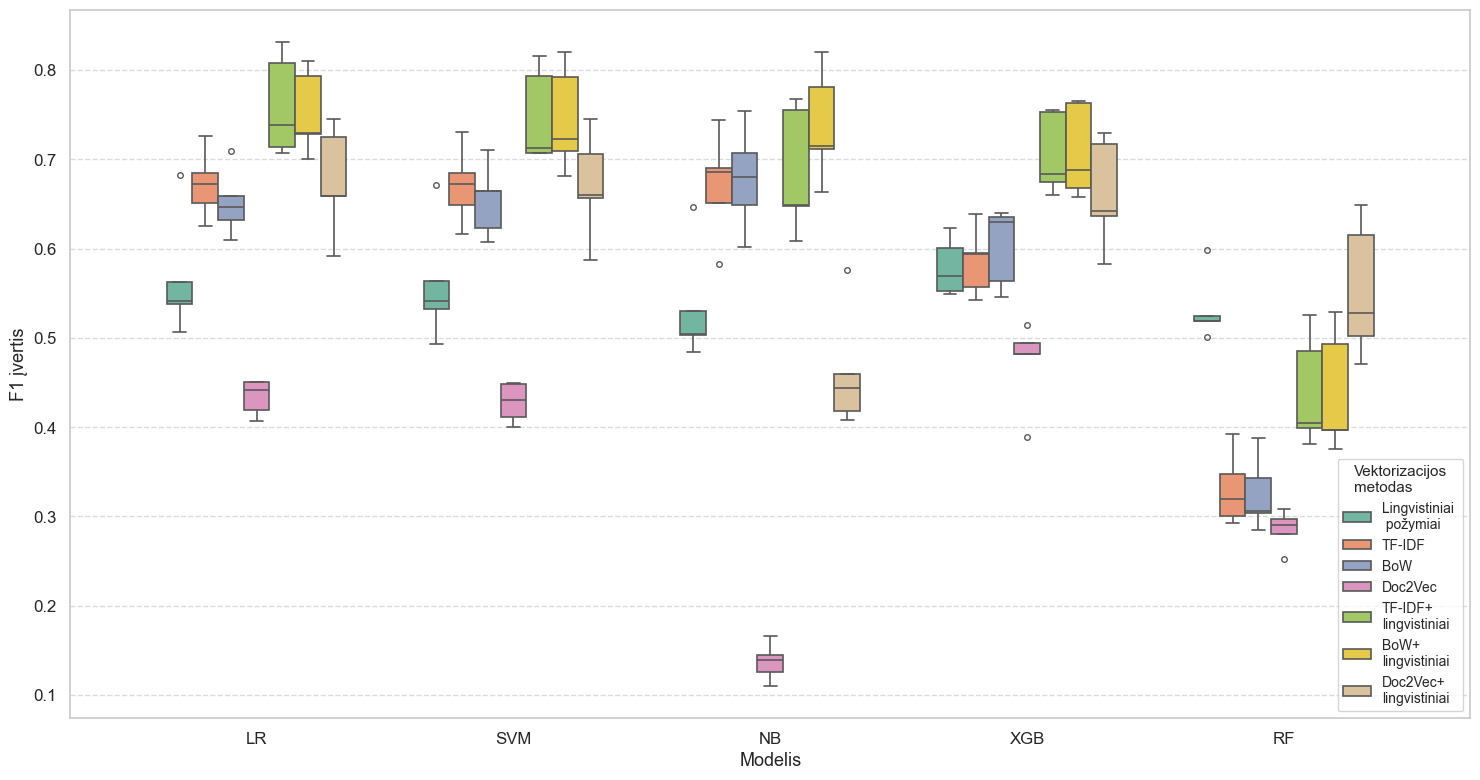

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = [
    {"Model": "LR", "Vectorization": "Lingvistiniai \n požymiai", "F1 Scores": cv_scores_lg_feat},
    {"Model": "LR", "Vectorization": "TF-IDF", "F1 Scores": cv_scores_lg_tfidf_text},
    {"Model": "LR", "Vectorization": "BoW", "F1 Scores": cv_scores_lg_cv_text},
    {"Model": "LR", "Vectorization": "Doc2Vec", "F1 Scores": cv_scores_lg_doc2vec},
    {"Model": "LR", "Vectorization": "TF-IDF+\nlingvistiniai", "F1 Scores": cv_scores_lg_tfidf_bendra},
    {"Model": "LR", "Vectorization": "BoW+\nlingvistiniai", "F1 Scores": cv_scores_lg_cv_bendra},
    {"Model": "LR", "Vectorization": "Doc2Vec+\nlingvistiniai", "F1 Scores": cv_scores_lr_doc2vec_bendra},
    {"Model": "SVM", "Vectorization": "Lingvistiniai \n požymiai", "F1 Scores": cv_scores_svm_feat},
    {"Model": "SVM", "Vectorization": "TF-IDF", "F1 Scores": cv_scores_svm_tfidf_text},
    {"Model": "SVM", "Vectorization": "BoW", "F1 Scores": cv_scores_svm_cv_text},
    {"Model": "SVM", "Vectorization": "Doc2Vec", "F1 Scores": cv_scores_svm_doc2vec},
    {"Model": "SVM", "Vectorization": "TF-IDF+\nlingvistiniai", "F1 Scores": cv_scores_svm_tfidf_bendra},
    {"Model": "SVM", "Vectorization": "BoW+\nlingvistiniai", "F1 Scores": cv_scores_svm_cv_bendra},
    {"Model": "SVM", "Vectorization": "Doc2Vec+\nlingvistiniai", "F1 Scores": cv_scores_svm_doc2vec_bendra},
    {"Model": "NB", "Vectorization": "Lingvistiniai \n požymiai", "F1 Scores": cv_scores_nb_feat},
    {"Model": "NB", "Vectorization": "TF-IDF", "F1 Scores": cv_scores_nb_tfidf_text},
    {"Model": "NB", "Vectorization": "BoW", "F1 Scores": cv_scores_nb_cv_text},
    {"Model": "NB", "Vectorization": "Doc2Vec", "F1 Scores": cv_scores_nb_doc2vec},
    {"Model": "NB", "Vectorization": "TF-IDF+\nlingvistiniai", "F1 Scores": cv_scores_nb_tfidf_bendra},
    {"Model": "NB", "Vectorization": "BoW+\nlingvistiniai", "F1 Scores": cv_scores_nb_cv_bendra},
    {"Model": "NB", "Vectorization": "Doc2Vec+\nlingvistiniai", "F1 Scores": cv_scores_nb_doc2vec_bendra},
    {"Model": "XGB", "Vectorization": "Lingvistiniai \n požymiai", "F1 Scores": cv_scores_xgb_feat},
    {"Model": "XGB", "Vectorization": "TF-IDF", "F1 Scores": cv_scores_xgb_tfidf_text},
    {"Model": "XGB", "Vectorization": "BoW", "F1 Scores": cv_scores_xgb_cv_text},
    {"Model": "XGB", "Vectorization": "Doc2Vec", "F1 Scores": cv_scores_xgb_doc2vec},
    {"Model": "XGB", "Vectorization": "TF-IDF+\nlingvistiniai", "F1 Scores": cv_scores_xgb_tfidf_bendra},
    {"Model": "XGB", "Vectorization": "BoW+\nlingvistiniai", "F1 Scores": cv_scores_xgb_cv_bendra},
    {"Model": "XGB", "Vectorization": "Doc2Vec+\nlingvistiniai", "F1 Scores": cv_scores_xgb_doc2vec_bendra},
    {"Model": "RF", "Vectorization": "Lingvistiniai \n požymiai", "F1 Scores": cv_scores_rf_feat},
    {"Model": "RF", "Vectorization": "TF-IDF", "F1 Scores": cv_scores_rf_tfidf_text},
    {"Model": "RF", "Vectorization": "BoW", "F1 Scores": cv_scores_rf_cv_text},
    {"Model": "RF", "Vectorization": "Doc2Vec", "F1 Scores": cv_scores_rf_doc2vec},
    {"Model": "RF", "Vectorization": "TF-IDF+\nlingvistiniai", "F1 Scores": cv_scores_rf_tfidf_bendra},
    {"Model": "RF", "Vectorization": "BoW+\nlingvistiniai", "F1 Scores": cv_scores_rf_cv_bendra},
    {"Model": "RF", "Vectorization": "Doc2Vec+\nlingvistiniai", "F1 Scores": cv_scores_rf_doc2vec_bendra}
]

# Convert results to a DataFrame for plotting
data = []
for result in results:
    for score in result["F1 Scores"]:
        data.append({"Model": result["Model"], "Vectorization": result["Vectorization"], "F1 Score": score})
df = pd.DataFrame(data)

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(15, 8))
sns.boxplot(
    x="Model",
    y="F1 Score",
    hue="Vectorization",
    data=df,
    palette="Set2",
    width=0.7,
    linewidth=1.2,
    fliersize=4,
    ax=ax
)

#ax.set_title("F1 įverčių pasiskirstymas pagal modelį ir vektorizacijos metodą", fontsize=16, pad=20)
ax.set_ylabel("F1 įvertis", fontsize=13)
ax.set_xlabel("Modelis", fontsize=13)
plt.xticks()
ax.margins(x=0.08)
ax.legend(title="Vektorizacijos\nmetodas", loc="lower right", frameon=True, fontsize=10, title_fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig("f1_scores_boxplot_improved.png", dpi=300, bbox_inches="tight")

In [103]:
best_lg_cv_bendra = gs_lg_cv_bendra.best_estimator_

print("Logistinės regresijos (BoW + lingvistiniai) požymių svoriai:")

# Feature names
feature_names_cv = (
    best_lg_cv_bendra
    .named_steps["preprocess"]
    .transformers_[0][1]
    .get_feature_names_out()
)

feature_names_num = (
    best_lg_cv_bendra
    .named_steps["preprocess"]
    .transformers_[1][2]
)

all_feature_names_cv = list(feature_names_cv) + feature_names_num

clf = best_lg_cv_bendra.named_steps["clf"]
classes = clf.classes_

for emotion_idx, emotion in enumerate(classes):

    print(f"\nEmocija: {emotion}")

    coef_cv = clf.coef_[emotion_idx]

    feature_importance_cv = pd.DataFrame({
        "Požymis": all_feature_names_cv,
        "Įvertis": coef_cv
    })

    # KEEP ONLY POSITIVE COEFFICIENTS
    feature_importance_cv = (
        feature_importance_cv[
            feature_importance_cv["Įvertis"] > 0
        ]
        .sort_values(
            by="Įvertis",
            ascending=False
        )
    )

    # Split feature types
    word_features = feature_importance_cv[
        feature_importance_cv["Požymis"].isin(feature_names_cv)
    ]

    numeric_features = feature_importance_cv[
        feature_importance_cv["Požymis"].isin(feature_names_num)
    ]

    print("\nTop 10 teigiami žodžių požymiai:")
    print(word_features.head(10))

    print("\nTop 10 teigiami skaitiniai požymiai:")
    print(numeric_features.head(10))

Logistinės regresijos (BoW + lingvistiniai) požymių svoriai:

Emocija: džiaugsmas

Top 10 teigiami žodžių požymiai:
           Požymis   Įvertis
3312    džiaugsmas  4.475349
3309   džiaugiuosi  3.629363
7448         laimė  3.592878
14659      puikiai  3.278292
5859        juokas  3.037507
20520   įspūdingas  2.964796
21135      šypsena  2.953322
5883       juokėsi  2.951988
3256        dėkoju  2.927514
137       akimirka  2.886968

Top 10 teigiami skaitiniai požymiai:
             Požymis   Įvertis
21597    n_semicolon  1.178927
21592  n_exclamation  0.849645
21611          pos_X  0.762828
21609       pos_INTJ  0.687241
21595        n_comma  0.548844
21603      pos_PROPN  0.448230
21606      pos_CCONJ  0.383661
21600        pos_ADJ  0.195642
21604        pos_ADP  0.134609
21586    n_stopwords  0.130613

Emocija: liūdesys

Top 10 teigiami žodžių požymiai:
           Požymis   Įvertis
7911        liūdna  3.983676
7907      liūdesys  3.416451
8359        mažoka  3.411420
13355    persirit

In [91]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

def emotion_dashboard_plotly(best_model):
    clf = best_model.named_steps["clf"]
    preprocess = best_model.named_steps["preprocess"]

    # Extract feature names
    vectorizer = preprocess.transformers_[0][1]
    feature_names_text = vectorizer.get_feature_names_out()
    feature_names_num = list(preprocess.transformers_[1][2])
    all_features = list(feature_names_text) + feature_names_num
    classes = clf.classes_

    def compute_df(emotion):
        idx = list(classes).index(emotion)
        coef = clf.coef_[idx]
        
        df = pd.DataFrame({
            "Feature": all_features,
            "Coefficient": coef
        })
        
        # --- SORTING LOGIC ---
        # Sort by raw value: Lowest (negative) to Biggest (positive)
        df = df.sort_values("Coefficient", ascending=True)

        # Get top 10 most influential features for each category 
        # (Top of list = most positive, Bottom of list = most negative)
        words = df[df["Feature"].isin(feature_names_text)].tail(10)
        nums = df[df["Feature"].isin(feature_names_num)].tail(10)
        
        return words, nums

    # Create FigureWidget
    fig = go.FigureWidget(make_subplots(
        rows=1, cols=2,
        subplot_titles=("Svarbiausi žodžiai", "Svarbiausi lingvistiniai požymiai")
    ))

    fig.add_trace(go.Bar(orientation="h", marker_color='royalblue'), row=1, col=1)
    fig.add_trace(go.Bar(orientation="h", marker_color='tomato'), row=1, col=2)

    fig.update_layout(
        height=550,
        showlegend=False,
        template="plotly_white",
        margin=dict(l=150)
    )

    def update_display(emotion):
        words, nums = compute_df(emotion)
        
        with fig.batch_update():
            # Update data: Plotly renders the last items in the DF at the top of the 'h' chart
            fig.data[0].x = words["Coefficient"]
            fig.data[0].y = words["Feature"]
            
            fig.data[1].x = nums["Coefficient"]
            fig.data[1].y = nums["Feature"]
            
            fig.layout.title.text = f"Požymių svarba — {emotion.upper()}"

    dropdown = widgets.Dropdown(
        options=classes,
        value=classes[0],
        description="Emocija:"
    )

    def on_change(change):
        update_display(change['new'])

    dropdown.observe(on_change, names='value')

    update_display(classes[0])
    display(widgets.VBox([dropdown, fig]))

# Run
emotion_dashboard_plotly(gs_lg_cv_bendra.best_estimator_)

# DEEP LEARNING #

In [92]:
from datasets import Dataset
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import evaluate

In [95]:
pip install transformers datasets evaluate scikit-learn torch
pip install -U transformers[torch]

SyntaxError: invalid syntax (1431150272.py, line 1)

In [104]:
df_dl = df_bendras[["sentence", "label"]].copy()
df_dl["label"] = df_dl["label"].astype("category").cat.codes
df_dl.rename(columns={"sentence": "text"}, inplace=True)

print(df_dl)

id2label = {
    0: "džiaugsmas",
    1: "liūdesys",
    2: "neutralus",
    3: "nuostaba",
    4: "pyktis"
}

label2id = {v: k for k, v in id2label.items()}

temp_df, test_df = train_test_split(
    df_dl,
    test_size=0.2,
    stratify=df_dl["label"],
    random_state=0
)

val_df, train_df = train_test_split(
    temp_df,
    test_size=0.75,
    stratify=temp_df["label"],
    random_state=0
)

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

                                                   text  label
0                        – Matai, kiek žibuoklių radau!      0
1                     Puikus buvo tada metas, vyručiai!      0
2              O dabar metas į puotą, kuri mūsų laukia!      0
3                          Linksminkitės, mano draugai!      0
4                                         – Kaip gražu!      0
...                                                 ...    ...
6936  Visgi, tėveliai dažniausiai išreiškia didelį d...      2
6937  – Kaip vertinate bendrą etninės kultūros ugdym...      2
6938  – Šia linkme nesu atlikusi specialių tyrimų, t...      2
6939  Juk be mokyklos, be ugdymo įstaigų, visko prad...      2
6940  Netgi, jei mokykloje ir nėra etninės kultūros ...      2

[6941 rows x 2 columns]


In [108]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

4164 1388 1389


In [105]:
df1 = test_dataset.to_pandas()
df2 = X_test_text

display(df1)
display(df2)

len(df1), len(df2)

,text,label,__index_level_0__
0,"Dink, šlykštus putino subinės laižytojau! Fui,...",4,4874
1,"Kas galėjo patikėti, kad trenginių sostinė iš ...",3,3734
2,Marš plytų krauti!,4,4900
3,Tu nepatikėsi – pasviręs Pizos bokštas ėmė sv...,3,4163
4,"Eik tu, nekalbėk nesąmonių, kas internete apie...",4,5744
...,...,...,...
1384,Rudens rytai gamtoje neapsakomas džiaugsmas ak...,0,1430
1385,Vilniuje privačiuose sklypuos bus naikinamos i...,2,6712
1386,"Ačiū už jūsų gerumą, išmintį ir gebėjimą pažad...",0,868
1387,"Ar girdėjai, kad kai kurios civilizacijos skai...",3,2934


4874    dink šlykštas putinti subinė laižytoti Fui vat...
3734    galėti patikėti trenginis sostinis tikro būti ...
4900                                    Marš plyti krauti
4163    nepatikėsi   pasvirti pizos bokštas imti svirt...
5744    Eik nekalbėk nesąmonis internetas tilti konstr...
                              ...                        
1430    Rudens rytai gamta neapsakomas džiaugsmas akis...
6712    Vilnius privačias sklypuos būti naikinamos inv...
868     gerumas išmintis gebėjimas pažadinti noras mok...
2934    girdėjas civilizacija skaičiavo laikas paukšči...
2425    Liūdna nepatekoti finalas trejose rungtynė kov...
Name: processed_sentence, Length: 1389, dtype: object

(1389, 1389)

## RoBERTA ##

In [109]:
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="macro"
    )

    return {
        "accuracy": acc["accuracy"],
        "macro_f1": f1["f1"]
    }

training_args = TrainingArguments(
    output_dir="./emotion_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    save_total_limit=2,
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

print("Validation results:")
val_results = trainer.evaluate(val_dataset)
print(val_results)

print("Test results:")
test_results = trainer.evaluate(test_dataset)
print(test_results)

trainer.save_model("final_lithuanian_emotion_model")
tokenizer.save_pretrained("final_lithuanian_emotion_model")

Map:   0%|          | 0/4164 [00:00<?, ? examples/s]

Map:   0%|          | 0/1388 [00:00<?, ? examples/s]

Map:   0%|          | 0/1389 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Using the latest cached version of the module from C:\Users\ignas\.cache\huggingface\modules\evaluate_modules

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.520145,0.358100,0.874640,0.873515
2,0.338575,0.324732,0.899135,0.900536
3,0.217373,0.380131,0.895533,0.895636
4,0.176494,0.417662,0.902017,0.903993
5,0.155676,0.438566,0.902017,0.903541


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:666: UserWarning:

'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:666: UserWarning:

'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:666: UserWarning:

'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:666: UserWarning:

'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Validation results:


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:666: UserWarning:

'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.



{'eval_loss': 0.4173189103603363, 'eval_accuracy': 0.9020172910662824, 'eval_macro_f1': 0.903993120577419, 'eval_runtime': 134.6186, 'eval_samples_per_second': 10.311, 'eval_steps_per_second': 0.646, 'epoch': 5.0}
Test results:


C:\Users\ignas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:666: UserWarning:

'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.



{'eval_loss': 0.4914950728416443, 'eval_accuracy': 0.8934485241180705, 'eval_macro_f1': 0.8948636216164596, 'eval_runtime': 131.692, 'eval_samples_per_second': 10.547, 'eval_steps_per_second': 0.661, 'epoch': 5.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('final_lithuanian_emotion_model\\tokenizer_config.json',
 'final_lithuanian_emotion_model\\tokenizer.json')